In [32]:
# ─────────────────────────────────────────
# CELL 1: Setup — Chest X-Ray Pneumonia (Kaggle)
# ─────────────────────────────────────────
# DATA: paultimothymooney/chest-xray-pneumonia
# STRUCTURE: chest_xray/{train,val,test}/{NORMAL,PNEUMONIA}/*.jpeg
# BINARY: NORMAL vs PNEUMONIA

!pip install shap -q

In [33]:
!find /kaggle/input -maxdepth 4 -type d | grep -i chest

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


In [34]:
# ─────────────────────────────────────────
# CELL 2: Build CSVs from folder tree (auto-find root)
# ─────────────────────────────────────────
import os, glob
import pandas as pd
from sklearn.model_selection import train_test_split

# walk /kaggle/input, find dir that contains train/NORMAL
DATA_ROOT = None
for root, dirs, _ in os.walk("/kaggle/input"):
    if os.path.isdir(os.path.join(root, "train", "NORMAL")):
        DATA_ROOT = root
        break
print("DATA_ROOT:", DATA_ROOT)
assert DATA_ROOT, "could not locate train/NORMAL anywhere under /kaggle/input"

rows = []
for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        d = os.path.join(DATA_ROOT, split, cls)
        if not os.path.isdir(d):
            print("  missing:", d); continue
        files = []
        for ext in ("jpeg","jpg","png","JPEG","JPG","PNG"):
            files += glob.glob(os.path.join(d, f"**/*.{ext}"), recursive=True)
        print(f"  {split}/{cls}: {len(files)}")
        for f in files:
            rows.append({"image_path": f, "label": cls})

df = pd.DataFrame(rows).drop_duplicates("image_path").reset_index(drop=True)
print("total:", len(df))
assert len(df) > 0, "no images found"
print(df["label"].value_counts())

train_df, tmp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df  = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df["label"], random_state=42)

os.makedirs("/kaggle/working/shuffled_csvs", exist_ok=True)
train_df.to_csv("/kaggle/working/shuffled_csvs/train_shuffled.csv", index=False)
val_df.to_csv  ("/kaggle/working/shuffled_csvs/val_shuffled.csv",   index=False)
test_df.to_csv ("/kaggle/working/shuffled_csvs/test_shuffled.csv",  index=False)
print(f"train={len(train_df)} val={len(val_df)} test={len(test_df)}")

DATA_ROOT: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
  train/NORMAL: 1341
  train/PNEUMONIA: 3875
  val/NORMAL: 8
  val/PNEUMONIA: 8
  test/NORMAL: 234
  test/PNEUMONIA: 390
total: 5856
label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64
train=4099 val=878 test=879


Preprocessing (CLAHE + lung crop)...


  test: 100%|██████████| 879/879 [00:44<00:00, 19.58it/s]



  done. train=4099 val=878 test=879
  class balance unchanged:
label
PNEUMONIA    2991
NORMAL       1108
Name: count, dtype: int64


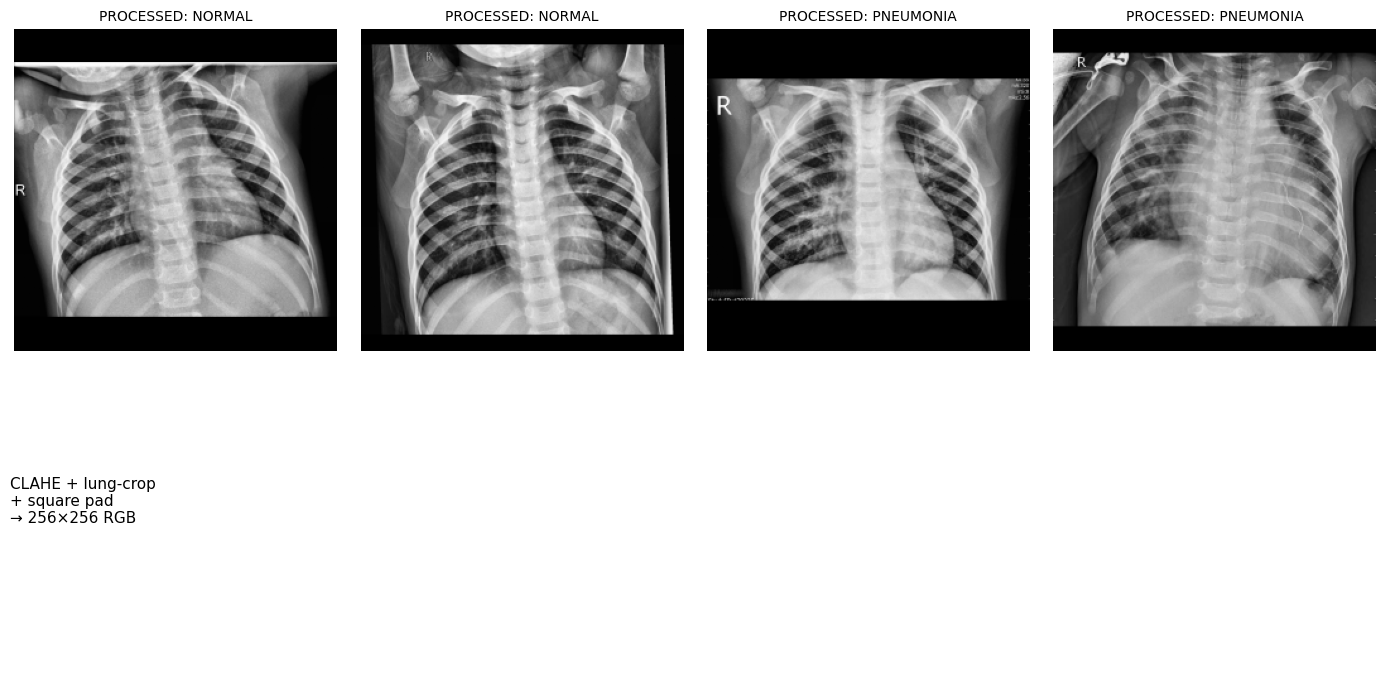

In [35]:
# ─────────────────────────────────────────
# CELL 2.5: Chest X-Ray Preprocessing
#   grayscale -> CLAHE -> lung-region crop -> square pad
#   (refs: Kermany 2018, Rahman 2020 COVID-QU-Ex)
#   writes cleaned imgs to /kaggle/working/preprocessed
#   rewrites the 3 CSVs to point at cleaned paths
#   NO resampling / NO SMOTE — distribution untouched
# ─────────────────────────────────────────
import os, cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

PREP_ROOT = "/kaggle/working/preprocessed"
os.makedirs(PREP_ROOT, exist_ok=True)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def lung_crop(gray):
    """
    Split image into left/right halves → find largest contour each side
    → merge bboxes → covers both lung fields even when one is consolidated
    (consolidated lung = dense → Otsu may miss it as background)
    """
    H, W = gray.shape
    # invert for consolidated (bright) regions
    _, th_normal = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, th_inv    = cv2.threshold(255 - gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    th_normal = cv2.morphologyEx(th_normal, cv2.MORPH_CLOSE, k, iterations=2)
    th_inv    = cv2.morphologyEx(th_inv,    cv2.MORPH_CLOSE, k, iterations=2)
    
    bboxes = []
    for th in [th_normal, th_inv]:
        # left lung
        left  = th[:, :W//2]
        cnts, _ = cv2.findContours(left,  cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 0.05 * H * (W//2):
                x, y, w, h = cv2.boundingRect(c)
                bboxes.append((x, y, x+w, y+h))
        # right lung
        right = th[:, W//2:]
        cnts, _ = cv2.findContours(right, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 0.05 * H * (W//2):
                x, y, w, h = cv2.boundingRect(c)
                bboxes.append((x + W//2, y, x + W//2 + w, y+h))
    
    if not bboxes:
        return gray  # fallback
    
    x0 = max(0, min(b[0] for b in bboxes) - int(0.03*W))
    y0 = max(0, min(b[1] for b in bboxes) - int(0.03*H))
    x1 = min(W, max(b[2] for b in bboxes) + int(0.03*W))
    y1 = min(H, max(b[3] for b in bboxes) + int(0.03*H))
    
    crop = gray[y0:y1, x0:x1]
    if crop.size == 0:
        return gray
    return crop

def square_pad(img):
    """pad to square (no distortion) before downstream Resize."""
    h, w = img.shape
    s = max(h, w)
    top, bot = (s - h) // 2, s - h - (s - h) // 2
    left, right = (s - w) // 2, s - w - (s - w) // 2
    return cv2.copyMakeBorder(img, top, bot, left, right,
                              cv2.BORDER_CONSTANT, value=0)

def preprocess_one(src_path, dst_path):
    img = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False
    img = clahe.apply(img)          # local contrast — boosts lung markings
    img = lung_crop(img)            # thoracic-field crop
    img = square_pad(img)           # keep aspect
    img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)
    rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)   # 3-ch for ResNet
    cv2.imwrite(dst_path, rgb)
    return True

def process_csv(csv_path, split_name):
    df = pd.read_csv(csv_path)
    out_dir = os.path.join(PREP_ROOT, split_name)
    os.makedirs(out_dir, exist_ok=True)
    new_paths, keep = [], []
    for i, row in tqdm(df.iterrows(), total=len(df), desc=f"  {split_name}"):
        src = row[cfg.IMG_COL] if 'cfg' in globals() else row["image_path"]
        dst = os.path.join(out_dir, f"{split_name}_{i:06d}.png")
        ok = preprocess_one(src, dst)
        new_paths.append(dst if ok else src)
        keep.append(True)
    df = df.copy()
    df["image_path"] = new_paths
    df.to_csv(csv_path, index=False)   # overwrite -> downstream uses cleaned
    return df

print("Preprocessing (CLAHE + lung crop)...")
tr = process_csv("/kaggle/working/shuffled_csvs/train_shuffled.csv", "train")
va = process_csv("/kaggle/working/shuffled_csvs/val_shuffled.csv",   "val")
te = process_csv("/kaggle/working/shuffled_csvs/test_shuffled.csv",  "test")
print(f"\n  done. train={len(tr)} val={len(va)} test={len(te)}")
print(f"  class balance unchanged:\n{tr['label'].value_counts()}")

# ── visual sanity: before vs after ──
import matplotlib.pyplot as plt
orig_df = pd.read_csv("/kaggle/working/shuffled_csvs/train_shuffled.csv")
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
sample = pd.concat([
    tr[tr.label=="NORMAL"].head(2),
    tr[tr.label=="PNEUMONIA"].head(2),
])
for j, (_, row) in enumerate(sample.iterrows()):
    axes[0, j].imshow(plt.imread(row["image_path"]), cmap="gray")
    axes[0, j].set_title(f"PROCESSED: {row['label']}", fontsize=10)
    axes[0, j].axis("off")
axes[1, 0].axis("off")
axes[1,0].text(0, 0.5, "CLAHE + lung-crop\n+ square pad\n→ 256×256 RGB", fontsize=11)
for j in range(1, 4): axes[1, j].axis("off")
plt.tight_layout(); plt.show()

In [36]:
# ─────────────────────────────────────────
# CELL 3: Imports
# ─────────────────────────────────────────
import os
import sys
import time
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

In [57]:
# ─────────────────────────────────────────
# CELL 4: Configuration
# ─────────────────────────────────────────
class Config:
    BASE_PATH  = "/kaggle/input/chest-xray-pneumonia/chest_xray"
    TRAIN_CSV  = "/kaggle/working/shuffled_csvs/train_shuffled.csv"
    VAL_CSV    = "/kaggle/working/shuffled_csvs/val_shuffled.csv"
    TEST_CSV   = "/kaggle/working/shuffled_csvs/test_shuffled.csv"
    IMAGE_ROOT = ""   # paths already absolute

    CHECKPOINT_DIR = "/kaggle/working/TAL_GRN_checkpoints"

    IMG_COL   = "image_path"
    LABEL_COL = "label"

    BACKBONE        = "resnet50"
    FEATURE_DIM     = 2048
    GNN_HIDDEN_DIM  = 512
    GNN_LAYERS      = 3
    NUM_CLASSES     = None

    K_BASE          = 5
    K_ALPHA         = 10
    EDGE_THRESHOLD  = 0.3
    REFINE_EVERY    = 2

    BATCH_SIZE      = 64
    EPOCHS          = 30          # binary, converges fast
    LR              = 1e-4
    WEIGHT_DECAY    = 1e-4
    IMG_SIZE        = 224
    SEED            = 42
    NUM_WORKERS     = 2
    RESUME          = False

    DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(cfg.SEED)
print(f"{'='*60}")
print(f"  TAL-GRN  |  Device: {cfg.DEVICE.upper()}")
print(f"{'='*60}")

  TAL-GRN  |  Device: CUDA


In [58]:
# ─────────────────────────────────────────
# CELL 5: Dataset
# ─────────────────────────────────────────
class ImageDataset(Dataset):
    def __init__(self, csv_path, image_root, img_col, label_col,
                 transform=None, label_map=None, img_size=224):
        self.df         = pd.read_csv(csv_path)
        self.image_root = image_root
        self.img_col    = img_col
        self.label_col  = label_col
        self.transform  = transform
        self.img_size   = img_size

        if label_map is None:
            unique = sorted(self.df[label_col].unique())
            self.label_map = {v: i for i, v in enumerate(unique)}
        else:
            self.label_map = label_map

        self.labels = [self.label_map[l] for l in self.df[label_col]]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        rel_path = self.df.iloc[idx][self.img_col]
        img_path = os.path.join(self.image_root, rel_path)
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (self.img_size, self.img_size))
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

def get_transforms(split="train"):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if split == "train":
        return transforms.Compose([
            transforms.Resize((cfg.IMG_SIZE + 32, cfg.IMG_SIZE + 32)),
            transforms.RandomCrop(cfg.IMG_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    return transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

def build_loaders():
    train_ds  = ImageDataset(cfg.TRAIN_CSV, cfg.IMAGE_ROOT,
                              cfg.IMG_COL, cfg.LABEL_COL,
                              get_transforms("train"), img_size=cfg.IMG_SIZE)
    label_map = train_ds.label_map
    cfg.NUM_CLASSES = len(label_map)

    val_ds   = ImageDataset(cfg.VAL_CSV,  cfg.IMAGE_ROOT,
                             cfg.IMG_COL, cfg.LABEL_COL,
                             get_transforms("val"), label_map, img_size=cfg.IMG_SIZE)
    test_ds  = ImageDataset(cfg.TEST_CSV, cfg.IMAGE_ROOT,
                             cfg.IMG_COL, cfg.LABEL_COL,
                             get_transforms("val"), label_map, img_size=cfg.IMG_SIZE)

    train_dl = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE,
                          shuffle=True,  num_workers=cfg.NUM_WORKERS, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE,
                          shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE,
                          shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)

    print(f"\n  Train: {len(train_ds):>6} | Val: {len(val_ds):>5} | Test: {len(test_ds):>5}")
    print(f"  Classes: {cfg.NUM_CLASSES}  -> {label_map}")
    return train_dl, val_dl, test_dl, label_map

In [59]:
# ─────────────────────────────────────────
# CELL 6: CNN Backbone (Frozen)
# ─────────────────────────────────────────
class FrozenBackbone(nn.Module):
    def __init__(self, arch="resnet50"):
        super().__init__()
        base = getattr(models, arch)(pretrained=True)
        self.features = nn.Sequential(*list(base.children())[:-1])
        for p in self.features.parameters():
            p.requires_grad = False

    def forward(self, x):
        out = self.features(x)
        return out.flatten(1)

In [60]:
# ─────────────────────────────────────────
# CELL 7: Adaptive Neighborhood MLP
# ─────────────────────────────────────────
class AdaptiveNeighborhoodMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, h):
        return self.net(h).squeeze(-1)

In [61]:
# ─────────────────────────────────────────
# CELL 8: Edge Weight Predictor
# ─────────────────────────────────────────
class EdgeWeightPredictor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim * 2 + 1, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, h_i, h_j, s_ij):
        e = torch.cat([h_i, h_j, s_ij], dim=-1)
        return F.softplus(self.net(e)).squeeze(-1)

In [62]:
# ─────────────────────────────────────────
# CELL 9: GNN Layer
# ─────────────────────────────────────────
class TALGRNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W_m  = nn.Linear(in_dim, out_dim, bias=False)
        self.W_u  = nn.Linear(in_dim + out_dim, out_dim)
        self.act  = nn.GELU()
        self.norm = nn.LayerNorm(out_dim)
        self.res  = nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity()

    def forward(self, h, adj_sparse):
        h_proj = self.W_m(h)
        with torch.cuda.amp.autocast(enabled=False):
            m = torch.sparse.mm(adj_sparse.float(), h_proj.float())
        m = m.to(h.dtype)
        h_new = self.act(self.W_u(torch.cat([h, m], dim=-1)))
        h_new = self.norm(h_new)
        return h_new + self.res(h)

In [63]:
# ─────────────────────────────────────────
# CELL 10: Graph Construction
# ─────────────────────────────────────────
def cosine_similarity_matrix(h):
    h_norm = F.normalize(h, p=2, dim=-1)
    return h_norm @ h_norm.T

def build_adaptive_graph(h, neighborhood_mlp, ewp, threshold=0.3):
    N = h.size(0)
    device = h.device

    S = cosine_similarity_matrix(h)

    with torch.no_grad():
        a = neighborhood_mlp(h)
    k_float = cfg.K_BASE + cfg.K_ALPHA * torch.sigmoid(a)
    k_int   = k_float.long().clamp(1, max(N - 1, 1))
    k_max   = int(k_int.max().item())

    S_no_self = S.clone()
    S_no_self.fill_diagonal_(-2.0)

    _, topk_idx = torch.topk(S_no_self, k_max, dim=1)

    k_range = torch.arange(k_max, device=device).unsqueeze(0)
    valid   = k_range < k_int.unsqueeze(1)

    row_idx = torch.arange(N, device=device).unsqueeze(1).expand(N, k_max)
    rows    = row_idx[valid]
    cols    = topk_idx[valid]

    h_i  = h[rows]
    h_j  = h[cols]
    s_ij = S[rows, cols].unsqueeze(-1)
    w    = ewp(h_i, h_j, s_ij)

    w = w.clamp(min=0.0, max=10.0)

    mask = w > threshold
    rows, cols, w = rows[mask], cols[mask], w[mask]

    self_idx = torch.arange(N, device=device)
    rows = torch.cat([rows, self_idx])
    cols = torch.cat([cols, self_idx])
    w    = torch.cat([w, torch.ones(N, device=device, dtype=w.dtype)])

    A_idx = torch.stack([rows, cols])
    A     = torch.sparse_coo_tensor(A_idx, w, (N, N)).coalesce()

    A_dense = A.to_dense()
    deg     = A_dense.sum(1)
    D_inv_sqrt = torch.zeros_like(deg)
    pos = deg > 0
    D_inv_sqrt[pos] = deg[pos].pow(-0.5)

    A_norm = D_inv_sqrt.unsqueeze(1) * A_dense * D_inv_sqrt.unsqueeze(0)
    A_norm = torch.nan_to_num(A_norm, nan=0.0, posinf=0.0, neginf=0.0)

    return A_norm.to_sparse()

In [64]:
# ─────────────────────────────────────────
# CELL 11: Full TAL-GRN Model
# ─────────────────────────────────────────
class TALGRN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        d = cfg.FEATURE_DIM
        H = cfg.GNN_HIDDEN_DIM

        self.backbone         = FrozenBackbone(cfg.BACKBONE)
        self.neighborhood_mlp = AdaptiveNeighborhoodMLP(d)
        self.ewp              = EdgeWeightPredictor(d)

        dims = [d] + [H] * cfg.GNN_LAYERS
        self.gnn_layers = nn.ModuleList([
            TALGRNLayer(dims[i], dims[i+1]) for i in range(cfg.GNN_LAYERS)
        ])

        self.classifier = nn.Linear(H, num_classes)

    def forward(self, x, return_features=False):
        h = self.backbone(x)

        A = build_adaptive_graph(
            h.detach(),
            self.neighborhood_mlp,
            self.ewp,
            threshold=cfg.EDGE_THRESHOLD
        )

        for layer in self.gnn_layers:
            h = layer(h, A)

        logits = self.classifier(h)

        if return_features:
            return logits, h
        return logits

In [65]:
# ─────────────────────────────────────────
# CELL 12: Metrics  (AUC FIXED for binary)
# ─────────────────────────────────────────
def compute_metrics(all_labels, all_preds, all_probs, num_classes, light=False):
    metrics = {}
    metrics["accuracy"] = accuracy_score(all_labels, all_preds)
    metrics["f1_macro"] = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    if light:
        for k in ["precision_macro", "recall_macro", "precision_weighted",
                  "recall_weighted", "f1_weighted", "roc_auc", "roc_auc_ovr", "roc_auc_ovo", "mcc"]:
            metrics[k] = float("nan")
        metrics["f1_per_class"] = np.array([])
        return metrics

    metrics["precision_macro"]    = precision_score(all_labels, all_preds, average="macro",    zero_division=0)
    metrics["recall_macro"]       = recall_score(   all_labels, all_preds, average="macro",    zero_division=0)
    metrics["precision_weighted"] = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    metrics["recall_weighted"]    = recall_score(   all_labels, all_preds, average="weighted", zero_division=0)
    metrics["f1_weighted"]        = f1_score(       all_labels, all_preds, average="weighted", zero_division=0)
    metrics["f1_per_class"]       = f1_score(       all_labels, all_preds, average=None,       zero_division=0)

    try:
        if num_classes == 2:
            # ── FIX: positive-class prob, fill all 3 AUC fields ──
            auc = roc_auc_score(all_labels, all_probs[:, 1])
            metrics["roc_auc"]     = auc
            metrics["roc_auc_ovr"] = auc
            metrics["roc_auc_ovo"] = auc
        else:
            y_bin = label_binarize(all_labels, classes=list(range(num_classes)))
            metrics["roc_auc_ovr"] = roc_auc_score(y_bin, all_probs, average="macro", multi_class="ovr")
            metrics["roc_auc_ovo"] = roc_auc_score(y_bin, all_probs, average="macro", multi_class="ovo")
            metrics["roc_auc"]     = metrics["roc_auc_ovr"]
    except Exception as e:
        print("  AUC error:", e)
        metrics["roc_auc"]     = float("nan")
        metrics["roc_auc_ovr"] = float("nan")
        metrics["roc_auc_ovo"] = float("nan")

    metrics["mcc"] = matthews_corrcoef(all_labels, all_preds)
    return metrics

In [66]:
# ─────────────────────────────────────────
# CELL 13: Evaluation Loop
# ─────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, criterion, num_classes, split="Val", light=False):
    model.eval()
    total_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []

    bar = tqdm(loader, desc=f"  {split:>5}", leave=False,
               bar_format="{l_bar}{bar:30}{r_bar}")

    for imgs, labels in bar:
        imgs, labels = imgs.to(cfg.DEVICE), labels.to(cfg.DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)

        probs = F.softmax(logits, dim=-1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_probs.append(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss   = total_loss / len(loader.dataset)
    all_probs  = np.vstack(all_probs)
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)

    metrics = compute_metrics(all_labels, all_preds, all_probs, num_classes, light=light)
    metrics["loss"] = avg_loss
    return metrics, all_labels, all_preds, all_probs

In [67]:
# ─────────────────────────────────────────
# CELL 14: Pretty Printer
# ─────────────────────────────────────────
def print_metrics(metrics, split="Val", epoch=None, num_classes=None, label_map=None):
    tag = f" [Epoch {epoch}] " if epoch else " "
    print(f"\n{'─'*60}")
    print(f"  {split.upper()}{tag}METRICS")
    print(f"{'─'*60}")
    print(f"  {'Loss':<30} {metrics['loss']:.4f}")
    print(f"  {'Accuracy':<30} {metrics['accuracy']*100:.2f}%")
    print(f"  {'Precision (Macro)':<30} {metrics['precision_macro']:.4f}")
    print(f"  {'Recall / Sensitivity (Macro)':<30} {metrics['recall_macro']:.4f}")
    print(f"  {'F1-Score (Macro)':<30} {metrics['f1_macro']:.4f}")
    print(f"  {'F1-Score (Weighted)':<30} {metrics['f1_weighted']:.4f}")
    print(f"  {'ROC-AUC':<30} {metrics['roc_auc']:.4f}")
    print(f"  {'MCC':<30} {metrics['mcc']:.4f}")
    print(f"{'─'*60}")

    if num_classes and num_classes <= 30 and len(metrics["f1_per_class"]) > 0:
        inv_map = {v: k for k, v in label_map.items()} if label_map else {}
        print(f"  Per-Class F1:")
        for c, f1 in enumerate(metrics["f1_per_class"]):
            cname = inv_map.get(c, str(c))
            bar   = "█" * int(f1 * 20) + "░" * (20 - int(f1 * 20))
            print(f"    {cname:<20} [{bar}] {f1:.3f}")
    print()

In [68]:
# ─────────────────────────────────────────
# CELL 15: Checkpoint Utilities
# ─────────────────────────────────────────
def save_checkpoint(state, path):
    torch.save(state, path)
    print(f"  ✔ Checkpoint saved → {path}")

def load_latest_checkpoint(model, optimizer, scheduler):
    ckpts = sorted(Path(cfg.CHECKPOINT_DIR).glob("epoch_*.pt"))
    if not ckpts:
        return 0, 0.0
    latest = ckpts[-1]
    print(f"  ↩ Resuming from {latest.name}")
    ck = torch.load(latest, map_location=cfg.DEVICE, weights_only=False)
    model.load_state_dict(ck["model"])
    optimizer.load_state_dict(ck["optimizer"])
    if scheduler and "scheduler" in ck:
        scheduler.load_state_dict(ck["scheduler"])
    return ck["epoch"], ck.get("best_f1", 0.0)

In [69]:
# ─────────────────────────────────────────
# CELL 16: Training Loop (AMP)
# ─────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, epoch, scaler):
    model.train()
    total_loss = 0.0
    correct, total = 0, 0

    bar = tqdm(loader, desc=f"  Epoch {epoch:>3}",
               bar_format="{l_bar}{bar:35}{r_bar}")

    for step, (imgs, labels) in enumerate(bar):
        imgs, labels = imgs.to(cfg.DEVICE), labels.to(cfg.DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        if not torch.isfinite(loss):
            print(f"  ⚠ non-finite loss ep{epoch} step{step} — skipped")
            optimizer.zero_grad()
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        preds = logits.detach().argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        bar.set_postfix({"loss": f"{loss.item():.4f}",
                         "acc": f"{100.*correct/max(total,1):.1f}%"})

    return total_loss / max(total, 1), correct / max(total, 1)


def train(model, train_dl, val_dl, label_map):
    # weighted loss -> pneumonia ~3x normal, helps balance
    df = pd.read_csv(cfg.TRAIN_CSV)
    counts = df["label"].map(label_map).value_counts().sort_index()
    w = (counts.sum() / (len(counts) * counts)).values
    class_w = torch.tensor(w, dtype=torch.float, device=cfg.DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_w)
    print(f"  class weights: {w}")

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    start_epoch, best_f1 = 0, 0.0
    if cfg.RESUME:
        start_epoch, best_f1 = load_latest_checkpoint(model, optimizer, scheduler)

    history = {"train_loss": [], "train_acc": [], "val_loss": [],
               "val_acc": [], "val_f1": [], "val_auc": [], "val_mcc": []}

    print(f"\n{'='*60}\n  Training from epoch {start_epoch+1}/{cfg.EPOCHS}\n{'='*60}\n")

    for epoch in range(start_epoch + 1, cfg.EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_dl, optimizer, criterion, epoch, scaler)

        # binary -> heavy every epoch (AUC cheap)
        val_metrics, _, _, _ = evaluate(model, val_dl, criterion, cfg.NUM_CLASSES, "Val", light=False)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1_macro"])
        history["val_auc"].append(val_metrics["roc_auc"])
        history["val_mcc"].append(val_metrics["mcc"])

        elapsed = time.time() - t0
        lr_now  = scheduler.get_last_lr()[0]
        print(f"  Ep {epoch:>3}/{cfg.EPOCHS}  TrLoss={tr_loss:.4f}  TrAcc={tr_acc*100:.1f}%  "
              f"ValLoss={val_metrics['loss']:.4f}  ValF1={val_metrics['f1_macro']:.4f}  "
              f"ValAUC={val_metrics['roc_auc']:.4f}  ValAcc={val_metrics['accuracy']*100:.1f}%  "
              f"LR={lr_now:.2e}  [{elapsed:.0f}s]")

        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            save_checkpoint({"epoch": epoch, "model": model.state_dict(), "best_f1": best_f1},
                            os.path.join(cfg.CHECKPOINT_DIR, "best_model.pt"))
            print(f"  ★ New best (F1={best_f1:.4f})")

        if epoch % 5 == 0 or epoch == cfg.EPOCHS:
            save_checkpoint({"epoch": epoch, "model": model.state_dict(),
                             "optimizer": optimizer.state_dict(),
                             "scheduler": scheduler.state_dict(),
                             "best_f1": best_f1, "metrics": val_metrics},
                            os.path.join(cfg.CHECKPOINT_DIR, f"epoch_{epoch:03d}.pt"))
            print_metrics(val_metrics, "Val", epoch, cfg.NUM_CLASSES, label_map)

    return history

In [70]:
# ─────────────────────────────────────────
# CELL 17: Training Curves
# ─────────────────────────────────────────
def plot_history(history, save_path=None):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("TAL-GRN Training History", fontsize=16, fontweight="bold")

    pairs = [
        ("Loss",     "train_loss", "val_loss",  "Train Loss", "Val Loss"),
        ("Accuracy", "train_acc",  "val_acc",   "Train Acc",  "Val Acc"),
        ("F1 Macro", None,         "val_f1",    None,         "Val F1"),
        ("ROC-AUC",  None,         "val_auc",   None,         "Val AUC"),
        ("MCC",      None,         "val_mcc",   None,         "Val MCC"),
    ]
    for ax, (title, tr_key, va_key, tr_label, va_label) in zip(axes.flatten(), pairs):
        epochs = list(range(1, len(history["val_loss"]) + 1))
        if tr_key and tr_key in history:
            ax.plot(epochs, history[tr_key], label=tr_label, color="#2196F3", linewidth=2)
        ax.plot(epochs, history[va_key], label=va_label, color="#FF5722", linewidth=2)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    axes[-1, -1].set_visible(False)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [71]:
# ─────────────────────────────────────────
# CELL 18: Confusion Matrix (better shape)
# ─────────────────────────────────────────
def plot_confusion_matrix(all_labels, all_preds, label_map, save_path=None):
    inv_map = {v: k for k, v in label_map.items()}
    class_names = [inv_map[i] for i in range(len(label_map))]
    n = len(class_names)
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    side = max(4.5, n * 1.1)
    fig, axes = plt.subplots(1, 2, figsize=(side*2.4, side))

    for ax, data, title, fmt in zip(
        axes, [cm, cm_norm],
        ["Confusion Matrix (Counts)", "Confusion Matrix (Normalized)"],
        ["d", ".3f"]):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=1.0, linecolor="white", square=True,
                    cbar_kws={"shrink": 0.6, "pad": 0.02},
                    annot_kws={'size': 14 if n<=5 else (8 if n<=20 else 6)})
        ax.set_title(title, fontweight="bold", fontsize=13, pad=14)
        ax.set_xlabel("Predicted", fontsize=11, labelpad=8)
        ax.set_ylabel("True", fontsize=11, labelpad=8)
        rot = 0 if n<=5 else 90
        ax.tick_params(axis='x', rotation=rot, labelsize=11 if n<=5 else 7)
        ax.tick_params(axis='y', rotation=0,  labelsize=11 if n<=5 else 7)

    fig.subplots_adjust(wspace=0.3, top=0.9, bottom=0.12, left=0.08, right=0.95)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"  CM saved → {save_path}")
    plt.show()

In [72]:
# ─────────────────────────────────────────
# CELL 19: Per-Class Bar Chart
# ─────────────────────────────────────────
def plot_per_class_metrics(all_labels, all_preds, label_map, save_path=None):
    inv_map   = {v: k for k, v in label_map.items()}
    class_names = [inv_map[i] for i in range(len(label_map))]
    prec = precision_score(all_labels, all_preds, average=None, zero_division=0)
    rec  = recall_score(   all_labels, all_preds, average=None, zero_division=0)
    f1   = f1_score(       all_labels, all_preds, average=None, zero_division=0)

    x = np.arange(len(class_names)); w = 0.25
    fig, ax = plt.subplots(figsize=(max(6, len(class_names) * 1.5), 5))
    ax.bar(x - w, prec, w, label="Precision", color="#42A5F5")
    ax.bar(x,     rec,  w, label="Recall",    color="#66BB6A")
    ax.bar(x + w, f1,   w, label="F1",        color="#FFA726")
    ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=0, ha="center")
    ax.set_ylim(0, 1.05)
    ax.set_title("Per-Class Precision / Recall / F1", fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [73]:
# ─────────────────────────────────────────
# CELL 20: Final Test Eval
# ─────────────────────────────────────────
def final_test(model, test_dl, label_map):
    criterion = nn.CrossEntropyLoss()
    best_ck = os.path.join(cfg.CHECKPOINT_DIR, "best_model.pt")
    if os.path.exists(best_ck):
        ck = torch.load(best_ck, map_location=cfg.DEVICE)
        model.load_state_dict(ck["model"])
        print(f"  Loaded best (epoch {ck['epoch']}, F1={ck['best_f1']:.4f})")

    test_metrics, all_labels, all_preds, all_probs = evaluate(
        model, test_dl, criterion, cfg.NUM_CLASSES, "Test")
    print_metrics(test_metrics, "TEST", num_classes=cfg.NUM_CLASSES, label_map=label_map)

    inv_map = {v: k for k, v in label_map.items()}
    class_names = [inv_map[i] for i in range(cfg.NUM_CLASSES)]
    print("\n  FULL CLASSIFICATION REPORT\n  " + "─"*58)
    report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
    for line in report.split("\n"):
        print("  " + line)

    plot_confusion_matrix(all_labels, all_preds, label_map,
                          save_path=os.path.join(cfg.CHECKPOINT_DIR, "confusion_matrix.png"))
    plot_per_class_metrics(all_labels, all_preds, label_map,
                           save_path=os.path.join(cfg.CHECKPOINT_DIR, "per_class_metrics.png"))
    return test_metrics


  Train:   4099 | Val:   878 | Test:   879
  Classes: 2  -> {'NORMAL': 0, 'PNEUMONIA': 1}
  Trainable params: 7,675,140
  class weights: [1.84972924 0.68522233]

  Training from epoch 1/30



  Epoch   1: 100%|███████████████████████████████████| 65/65 [00:12<00:00,  5.22it/s, loss=0.2309, acc=81.6%]


  Ep   1/30  TrLoss=0.6141  TrAcc=81.6%  ValLoss=0.3076  ValF1=0.8871  ValAUC=0.9695  ValAcc=91.6%  LR=9.97e-05  [15s]
  ✔ Checkpoint saved → /kaggle/working/TAL_GRN_checkpoints/single/best_model.pt
  ★ New best (F1=0.8871)


  Epoch   2: 100%|███████████████████████████████████| 65/65 [00:12<00:00,  5.14it/s, loss=1.0140, acc=88.9%]


  Ep   2/30  TrLoss=0.2930  TrAcc=88.9%  ValLoss=0.7187  ValF1=0.7472  ValAUC=0.9747  ValAcc=84.3%  LR=9.89e-05  [16s]


...

  Ep  28/30  TrLoss=0.1301  TrAcc=94.9%  ValLoss=0.3170  ValF1=0.8894  ValAUC=0.9810  ValAcc=91.9%  LR=1.09e-06  [15s]


  Epoch  29: 100%|███████████████████████████████████| 65/65 [00:12<00:00,  5.21it/s, loss=0.0010, acc=95.4%]


  Ep  29/30  TrLoss=0.1249  TrAcc=95.4%  ValLoss=0.3755  ValF1=0.8763  ValAUC=0.9810  ValAcc=91.1%  LR=2.74e-07  [16s]


  Epoch  30: 100%|███████████████████████████████████| 65/65 [00:12<00:00,  5.19it/s, loss=0.0088, acc=94.9%]


  Ep  30/30  TrLoss=0.1283  TrAcc=94.9%  ValLoss=0.3466  ValF1=0.8736  ValAUC=0.9794  ValAcc=90.9%  LR=0.00e+00  [16s]
  ✔ Checkpoint saved → /kaggle/working/TAL_GRN_checkpoints/single/epoch_030.pt

────────────────────────────────────────────────────────────
  VAL [Epoch 30] METRICS
────────────────────────────────────────────────────────────
  Loss                           0.3466
  Accuracy                       90.89%
  Precision (Macro)              0.9218
  Recall / Sensitivity (Macro)   0.8445
  F1-Score (Macro)               0.8736
  F1-Score (Weighted)            0.9043
  ROC-AUC                        0.9794
  MCC                            0.7624
────────────────────────────────────────────────────────────
  Per-Class F1:
    NORMAL               [████████████████░░░░] 0.807
    PNEUMONIA            [██████████████████░░] 0.940



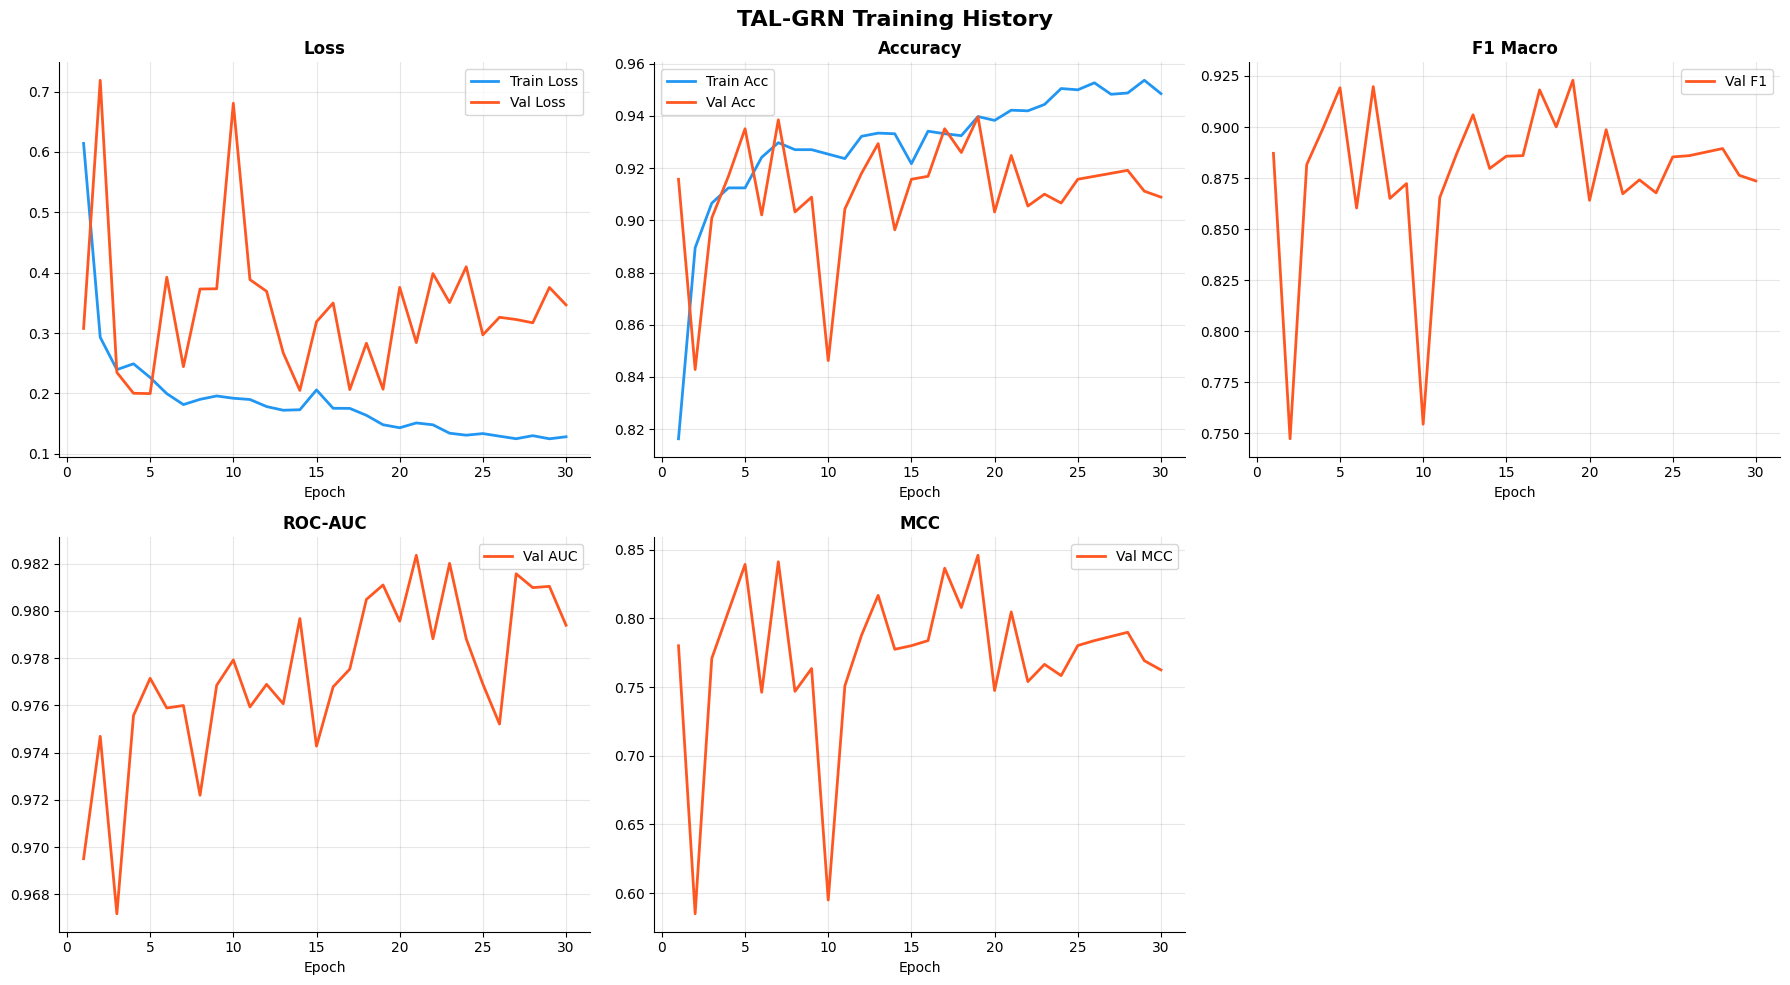

  Loaded best (epoch 19, F1=0.9229)



────────────────────────────────────────────────────────────
  TEST METRICS
────────────────────────────────────────────────────────────
  Loss                           0.1717
  Accuracy                       93.52%
  Precision (Macro)              0.9233
  Recall / Sensitivity (Macro)   0.9106
  F1-Score (Macro)               0.9167
  F1-Score (Weighted)            0.9347
  ROC-AUC                        0.9747
  MCC                            0.8338
────────────────────────────────────────────────────────────
  Per-Class F1:
    NORMAL               [█████████████████░░░] 0.877
    PNEUMONIA            [███████████████████░] 0.956


  FULL CLASSIFICATION REPORT
  ──────────────────────────────────────────────────────────
                precision    recall  f1-score   support
  
        NORMAL       0.90      0.86      0.88       238
     PNEUMONIA       0.95      0.96      0.96       641
  
      accuracy                           0.94       879
     macro avg       0.92      0.91

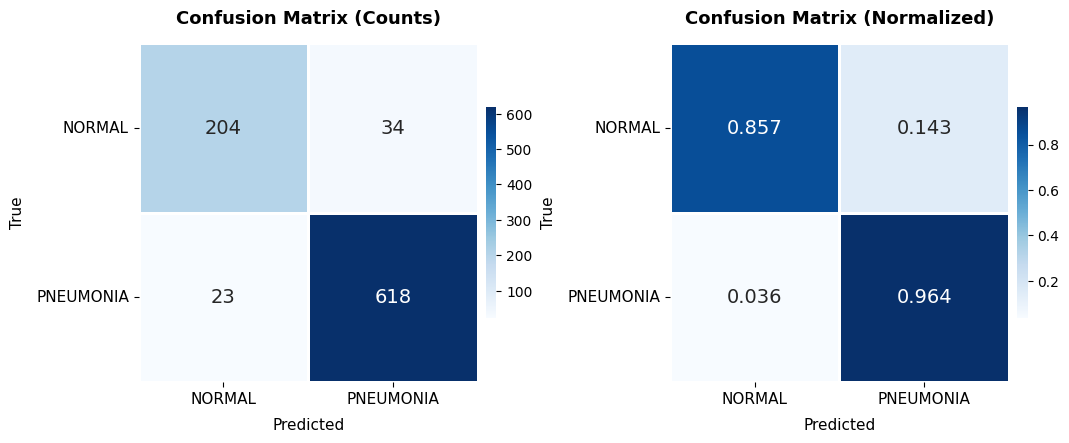

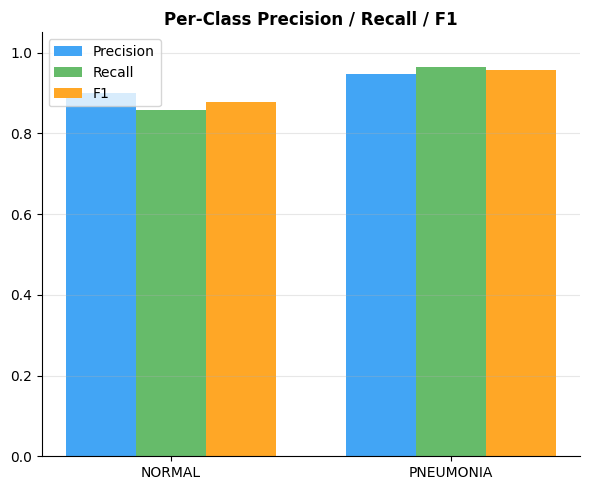

In [74]:
# ══════════════════════════════════════════════════════════════
#  CELL 21: SINGLE RUN (sanity) — train + test once
# ══════════════════════════════════════════════════════════════
cfg.SEED = 42; cfg.RESUME = False; cfg.NUM_CLASSES = None
cfg.CHECKPOINT_DIR = "/kaggle/working/TAL_GRN_checkpoints/single"
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
set_seed(42)

train_dl, val_dl, test_dl, label_map = build_loaders()
model = TALGRN(num_classes=cfg.NUM_CLASSES).to(cfg.DEVICE)
print(f"  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

history = train(model, train_dl, val_dl, label_map)
plot_history(history)
test_metrics = final_test(model, test_dl, label_map)


  VANILLA ResNet50 + FC BASELINE
  Trainable params: 4,098

  Training 30 epochs...



  Epoch   1: 100%|███████████████████████████████████| 65/65 [00:12<00:00,  5.32it/s, loss=0.3657, acc=79.8%]


  Ep   1/30  TrLoss=0.5575  TrAcc=79.8%  ValLoss=0.4817  ValF1=0.8726  ValAUC=0.9628  ValAcc=90.8%  [15s]
  ★ New best (F1=0.8726)


  Epoch   2: 100%|███████████████████████████████████| 65/65 [00:12<00:00,  5.37it/s, loss=0.5371, acc=89.3%]


  Ep   2/30  TrLoss=0.3766  TrAcc=89.3%  ValLoss=0.3947  ValF1=0.8486  ValAUC=0.9643  ValAcc=89.2%  [15s]


...

  Epoch  29: 100%|███████████████████████████████████| 65/65 [00:12<00:00,  5.32it/s, loss=0.6806, acc=91.8%]


  Ep  29/30  TrLoss=0.2098  TrAcc=91.8%  ValLoss=0.2512  ValF1=0.9135  ValAUC=0.9743  ValAcc=93.3%  [15s]


  Epoch  30: 100%|███████████████████████████████████| 65/65 [00:12<00:00,  5.31it/s, loss=0.1461, acc=91.7%]


  Ep  30/30  TrLoss=0.2086  TrAcc=91.7%  ValLoss=0.2719  ValF1=0.9041  ValAUC=0.9736  ValAcc=92.7%  [15s]

────────────────────────────────────────────────────────────
  VAL [Epoch 30] METRICS
────────────────────────────────────────────────────────────
  Loss                           0.2719
  Accuracy                       92.71%
  Precision (Macro)              0.9212
  Recall / Sensitivity (Macro)   0.8902
  F1-Score (Macro)               0.9041
  F1-Score (Weighted)            0.9257
  ROC-AUC                        0.9736
  MCC                            0.8109
────────────────────────────────────────────────────────────
  Per-Class F1:
    NORMAL               [█████████████████░░░] 0.857
    PNEUMONIA            [███████████████████░] 0.951


  VANILLA BASELINE — FINAL TEST
  Loaded best (epoch 25, F1=0.9155)



────────────────────────────────────────────────────────────
  TEST METRICS
────────────────────────────────────────────────────────────
  Loss                           0.2653
  Accuracy                       91.47%
  Precision (Macro)              0.8956
  Recall / Sensitivity (Macro)   0.8860
  F1-Score (Macro)               0.8907
  F1-Score (Weighted)            0.9142
  ROC-AUC                        0.9648
  MCC                            0.7816
────────────────────────────────────────────────────────────
  Per-Class F1:
    NORMAL               [████████████████░░░░] 0.839
    PNEUMONIA            [██████████████████░░] 0.942


  CLASSIFICATION REPORT
  ──────────────────────────────────────────────────────────
                precision    recall  f1-score   support
  
        NORMAL       0.86      0.82      0.84       238
     PNEUMONIA       0.94      0.95      0.94       641
  
      accuracy                           0.91       879
     macro avg       0.90      0.89     

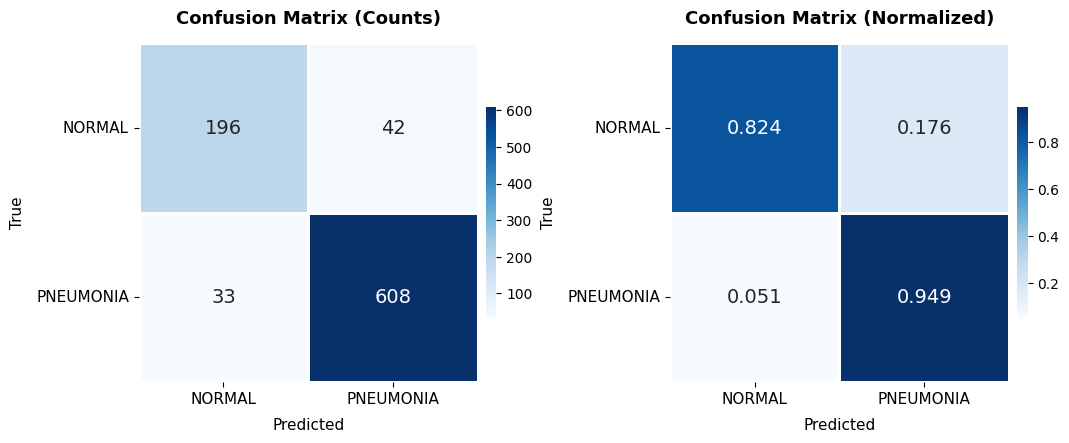

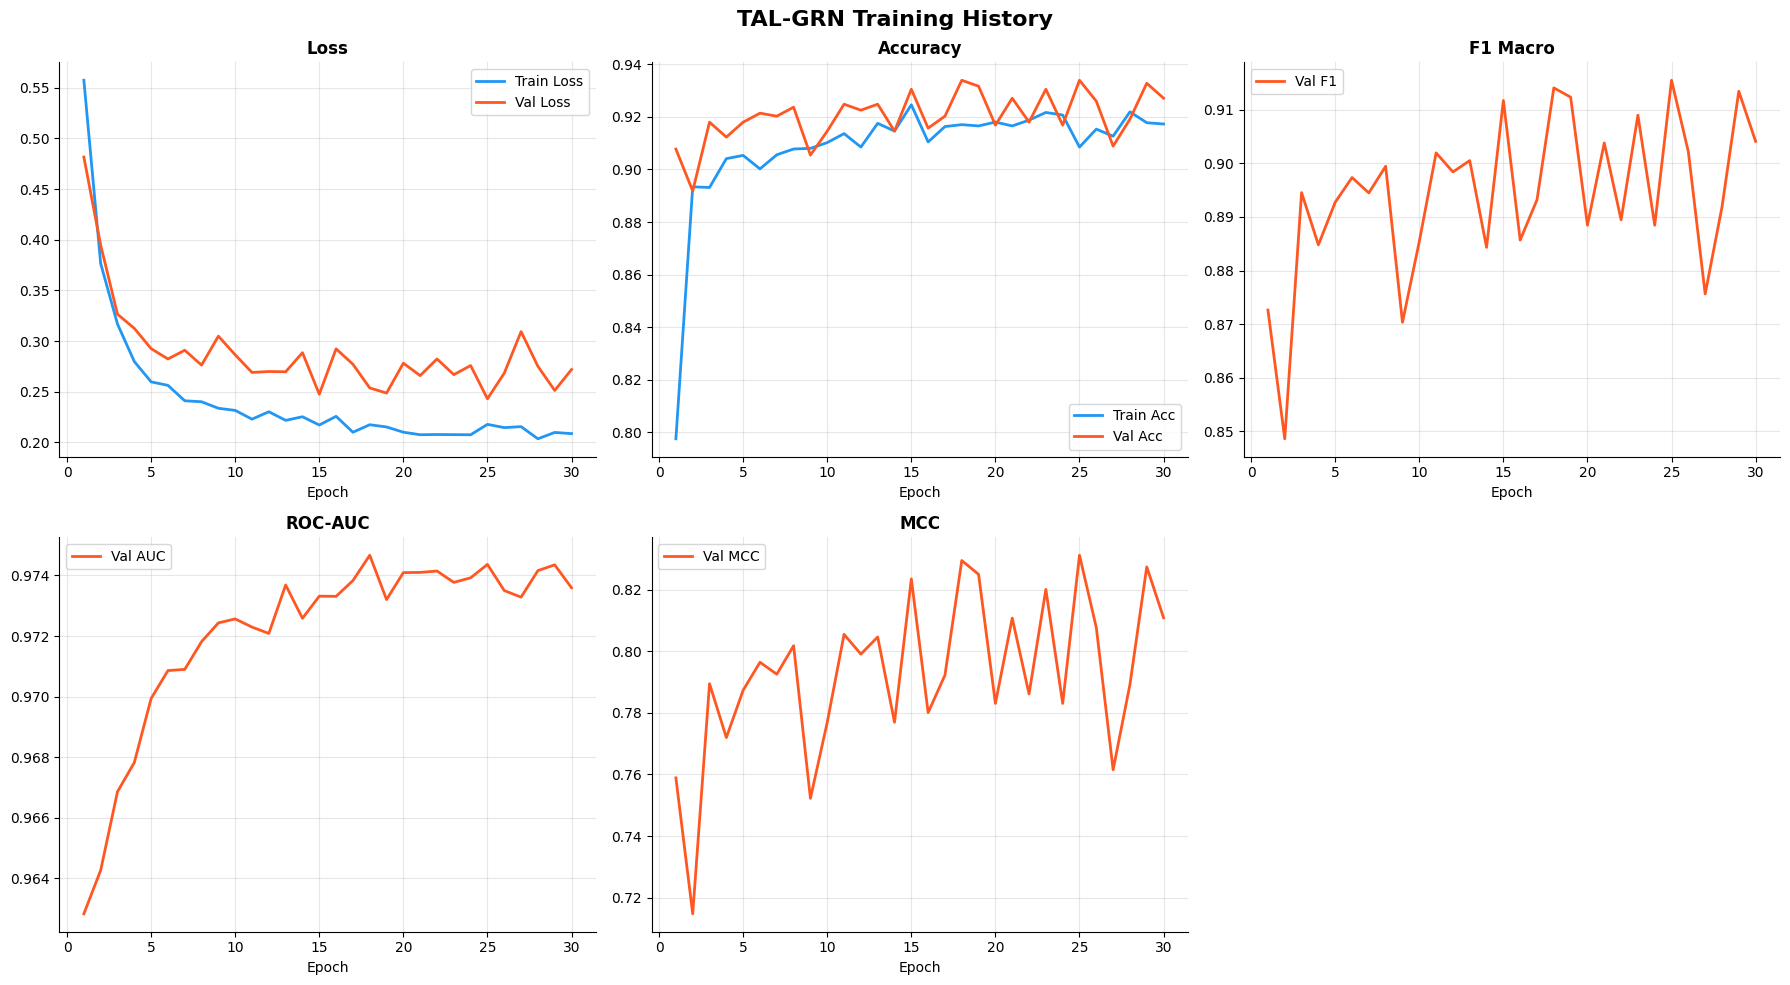


  COMPARISON SUMMARY
  Metric                       TAL-GRN    Vanilla
  ─────────────────────────────────────────────
  Accuracy                      0.9352     0.9147 ◄
  F1 Macro                      0.9167     0.8907 ◄
  ROC-AUC                       0.9747     0.9648 ◄
  MCC                           0.8338     0.7816 ◄


In [77]:
# ─────────────────────────────────────────
# CELL 24: Vanilla ResNet50 + FC Baseline (frozen backbone)
# ─────────────────────────────────────────
class VanillaResNet50(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.resnet50(pretrained=True)
        self.features = nn.Sequential(*list(base.children())[:-1])
        for p in self.features.parameters():
            p.requires_grad = False
        self.classifier = nn.Linear(2048, num_classes)

    def forward(self, x):
        h = self.features(x).flatten(1)
        return self.classifier(h)

print("\n" + "="*60)
print("  VANILLA ResNet50 + FC BASELINE")
print("="*60)

vanilla_ckpt_dir = "/kaggle/working/TAL_GRN_checkpoints/vanilla_baseline"
os.makedirs(vanilla_ckpt_dir, exist_ok=True)

set_seed(cfg.SEED)
v_model = VanillaResNet50(num_classes=cfg.NUM_CLASSES).to(cfg.DEVICE)
print(f"  Trainable params: {sum(p.numel() for p in v_model.parameters() if p.requires_grad):,}")

# reuse same loaders — label_map already set
df_tr = pd.read_csv(cfg.TRAIN_CSV)
counts = df_tr["label"].map(label_map).value_counts().sort_index()
w = (counts.sum() / (len(counts) * counts)).values
class_w = torch.tensor(w, dtype=torch.float, device=cfg.DEVICE)
v_criterion = nn.CrossEntropyLoss(weight=class_w)

v_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, v_model.parameters()),
    lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY
)
v_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(v_optimizer, T_max=cfg.EPOCHS)
v_scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

v_history = {"train_loss": [], "train_acc": [], "val_loss": [],
             "val_acc": [], "val_f1": [], "val_auc": [], "val_mcc": []}

best_v_f1 = 0.0
print(f"\n  Training {cfg.EPOCHS} epochs...\n")

for epoch in range(1, cfg.EPOCHS + 1):
    t0 = time.time()
    v_model.train()
    total_loss, correct, total = 0.0, 0, 0

    bar = tqdm(train_dl, desc=f"  Epoch {epoch:>3}",
               bar_format="{l_bar}{bar:35}{r_bar}")
    for imgs, labels in bar:
        imgs, labels = imgs.to(cfg.DEVICE), labels.to(cfg.DEVICE)
        v_optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = v_model(imgs)
            loss   = v_criterion(logits, labels)
        v_scaler.scale(loss).backward()
        v_scaler.unscale_(v_optimizer)
        torch.nn.utils.clip_grad_norm_(v_model.parameters(), 1.0)
        v_scaler.step(v_optimizer)
        v_scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.detach().argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        bar.set_postfix({"loss": f"{loss.item():.4f}",
                         "acc":  f"{100.*correct/max(total,1):.1f}%"})

    tr_loss = total_loss / max(total, 1)
    tr_acc  = correct    / max(total, 1)

    v_metrics, _, _, _ = evaluate(v_model, val_dl, v_criterion, cfg.NUM_CLASSES, "Val")
    v_scheduler.step()

    v_history["train_loss"].append(tr_loss)
    v_history["train_acc"].append(tr_acc)
    v_history["val_loss"].append(v_metrics["loss"])
    v_history["val_acc"].append(v_metrics["accuracy"])
    v_history["val_f1"].append(v_metrics["f1_macro"])
    v_history["val_auc"].append(v_metrics["roc_auc"])
    v_history["val_mcc"].append(v_metrics["mcc"])

    elapsed = time.time() - t0
    print(f"  Ep {epoch:>3}/{cfg.EPOCHS}  TrLoss={tr_loss:.4f}  TrAcc={tr_acc*100:.1f}%  "
          f"ValLoss={v_metrics['loss']:.4f}  ValF1={v_metrics['f1_macro']:.4f}  "
          f"ValAUC={v_metrics['roc_auc']:.4f}  ValAcc={v_metrics['accuracy']*100:.1f}%  "
          f"[{elapsed:.0f}s]")

    if v_metrics["f1_macro"] > best_v_f1:
        best_v_f1 = v_metrics["f1_macro"]
        torch.save({"epoch": epoch, "model": v_model.state_dict(), "best_f1": best_v_f1},
                   os.path.join(vanilla_ckpt_dir, "best_model.pt"))
        print(f"  ★ New best (F1={best_v_f1:.4f})")

    if epoch % 5 == 0 or epoch == cfg.EPOCHS:
        print_metrics(v_metrics, "Val", epoch, cfg.NUM_CLASSES, label_map)

# ── Test ──
print("\n" + "="*60 + "\n  VANILLA BASELINE — FINAL TEST\n" + "="*60)
ck = torch.load(os.path.join(vanilla_ckpt_dir, "best_model.pt"), map_location=cfg.DEVICE)
v_model.load_state_dict(ck["model"])
print(f"  Loaded best (epoch {ck['epoch']}, F1={ck['best_f1']:.4f})")

v_test_metrics, v_labels, v_preds, v_probs = evaluate(
    v_model, test_dl, v_criterion, cfg.NUM_CLASSES, "Test")
print_metrics(v_test_metrics, "TEST", num_classes=cfg.NUM_CLASSES, label_map=label_map)

inv_map = {v: k for k, v in label_map.items()}
class_names = [inv_map[i] for i in range(cfg.NUM_CLASSES)]
print("\n  CLASSIFICATION REPORT\n  " + "─"*58)
for line in classification_report(v_labels, v_preds, target_names=class_names, zero_division=0).split("\n"):
    print("  " + line)

plot_confusion_matrix(v_labels, v_preds, label_map,
                      save_path=os.path.join(vanilla_ckpt_dir, "confusion_matrix.png"))
plot_history(v_history)

# ── Side-by-side summary ──
print("\n" + "="*60)
print("  COMPARISON SUMMARY")
print("="*60)
print(f"  {'Metric':<25} {'TAL-GRN':>10} {'Vanilla':>10}")
print(f"  {'─'*45}")
for k, label in [("accuracy","Accuracy"), ("f1_macro","F1 Macro"),
                  ("roc_auc","ROC-AUC"), ("mcc","MCC")]:
    tg = test_metrics.get(k, float("nan"))
    vn = v_test_metrics.get(k, float("nan"))
    flag = " ◄" if tg > vn else ("  " if tg == vn else " ▼")
    print(f"  {label:<25} {tg:>10.4f} {vn:>10.4f}{flag}")
print("="*60)

✅ Grad-CAM saved → /kaggle/working/TAL_GRN_checkpoints/single/gradcam.png


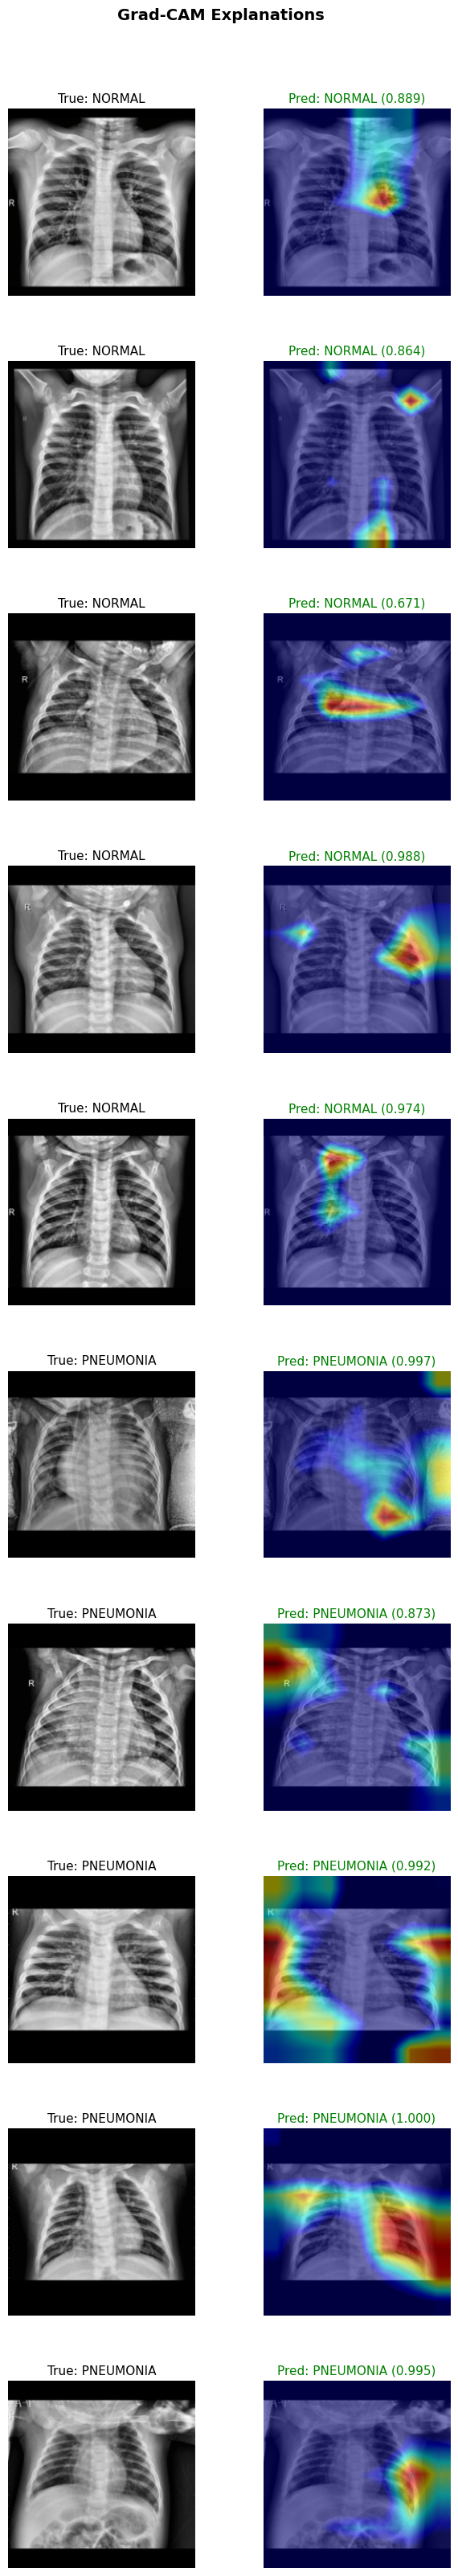

In [78]:
# ══════════════════════════════════════════════════════════════
# CELL 22: GRAD-CAM (robust FrozenBackbone-safe version)
# ══════════════════════════════════════════════════════════════
import cv2
import torch
import torch.nn.functional as F
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# =========================
# SAFE LAYER FINDER (Improved)
# =========================
def find_last_conv_layer(model):
    base = model.backbone if hasattr(model, 'backbone') else model
    
    # Unwrap common wrappers
    for attr in ["model", "net", "encoder", "features", "backbone", "body", "module"]:
        if hasattr(base, attr):
            base = getattr(base, attr)
    
    # Try common final blocks first
    candidates = ["layer4", "features", "stage4", "block4", "conv_head", "head"]
    for name in candidates:
        if hasattr(base, name):
            layer = getattr(base, name)
            if isinstance(layer, torch.nn.Sequential) or isinstance(layer, torch.nn.ModuleList):
                # Return the last convolutional block
                for m in reversed(list(layer.modules())):
                    if isinstance(m, torch.nn.Conv2d):
                        return m
            return layer
    
    # Fallback: last Conv2d in the entire model
    last_conv = None
    for m in reversed(list(base.modules())):
        if isinstance(m, torch.nn.Conv2d):
            last_conv = m
            break
    if last_conv is None:
        raise RuntimeError("No Conv2d layer found for Grad-CAM")
    return last_conv

# =========================
# GRAD-CAM ENGINE
# =========================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.acts = None
        self.grads = None
        self.fwd = target_layer.register_forward_hook(self._forward)
        self.bwd = target_layer.register_full_backward_hook(self._backward)
    
    def _forward(self, m, i, o):
        self.acts = o.detach()  # detach to save memory
    
    def _backward(self, m, gi, go):
        self.grads = go[0].detach()  # detach gradients
    
    def remove(self):
        self.fwd.remove()
        self.bwd.remove()
    
    def __call__(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)
        
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        
        score = logits[:, class_idx].sum()
        self.model.zero_grad(set_to_none=True)
        score.backward(retain_graph=True)  # safer
        
        if self.grads is None:
            raise RuntimeError("Grad-CAM failed: no gradients captured")
        
        # Global Average Pooling on gradients
        weights = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        
        # Upsample to original image size
        cam = F.interpolate(cam, size=x.shape[2:], mode="bilinear", align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy()
        
        # Normalize
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]
        return cam, class_idx, probs

# =========================
# HELPERS
# =========================
def denorm(t):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = t.detach().cpu().numpy().transpose(1, 2, 0)
    return (img * std + mean).clip(0, 1)

def overlay_cam(img, cam, label, threshold_normal=0.4, threshold_pneumonia=0.25):
    thresh = threshold_pneumonia if label == "PNEUMONIA" else threshold_normal
    cam = np.maximum(cam - thresh, 0)
    cam = cam / (cam.max() + 1e-8)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * img + 0.5 * heatmap
    return overlay.clip(0, 1)
    # rest of overlay...

# =========================
# MAIN RUN FUNCTION (Fixed)
# =========================
def run_gradcam(model, label_map, n_per_class=3):
    inv_map = {v: k for k, v in label_map.items()}
    
    # Load best model
    best_ck = os.path.join(cfg.CHECKPOINT_DIR, "best_model.pt")
    if os.path.exists(best_ck):
        checkpoint = torch.load(best_ck, map_location=cfg.DEVICE)
        model.load_state_dict(checkpoint["model"])
    
    model.to(cfg.DEVICE)
    
    # === FROZEN BACKBONE SAFETY ===
    # Enable gradients only where needed for Grad-CAM
    for param in model.parameters():
        param.requires_grad = False
    
    target_layer = find_last_conv_layer(model)
    for param in target_layer.parameters():
        param.requires_grad = True
    
    # Also ensure classifier head has gradients
    for name, param in model.named_parameters():
        if any(key in name.lower() for key in ["classifier", "fc", "head", "dense"]):
            param.requires_grad = True
    
    model.eval()
    
    # Initialize Grad-CAM
    cam_engine = GradCAM(model, target_layer)
    
    # Load test data
    test_df = pd.read_csv(cfg.TEST_CSV)
    tf = get_transforms("val")
    
    # Sample images per class
    picks = []
    for cls_name in inv_map.values():
        m = test_df[cfg.LABEL_COL] == cls_name
        sub = test_df[m].sample(min(n_per_class, int(m.sum())), random_state=10)
        picks.append((cls_name, sub))
    
    total = sum(len(s) for _, s in picks)
    fig, axes = plt.subplots(total, 2, figsize=(8, 3.6 * total))
    if total == 1:
        axes = axes[None, :]
    
    r = 0
    for cls_name, sub in picks:
        for _, row in sub.iterrows():
            # Load and transform image
            img_pil = Image.open(row[cfg.IMG_COL]).convert("RGB")
            x = tf(img_pil).unsqueeze(0).to(cfg.DEVICE)
            
            # === Grad-CAM (NO torch.no_grad!) ===
            cam, pred_idx, probs = cam_engine(x)
            
            img = denorm(x[0])
            
            # line 171 — pass label
            over = overlay_cam(img, cam, cls_name)
            # Left: Original
            axes[r, 0].imshow(img)
            axes[r, 0].axis("off")
            axes[r, 0].set_title(f"True: {cls_name}", fontsize=11)
            
            # Right: Grad-CAM
            axes[r, 1].imshow(over)
            axes[r, 1].axis("off")
            
            ok = inv_map.get(pred_idx, "Unknown") == cls_name
            axes[r, 1].set_title(
                f"Pred: {inv_map.get(pred_idx, 'Unknown')} ({probs[pred_idx]:.3f})",
                fontsize=11,
                color="green" if ok else "red"
            )
            r += 1
    
    cam_engine.remove()
    
    fig.suptitle("Grad-CAM Explanations", fontweight="bold", fontsize=14, y=0.995)
    fig.subplots_adjust(top=0.96, hspace=0.35, wspace=0.05)
    
    save_path = os.path.join(cfg.CHECKPOINT_DIR, "gradcam.png")
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    print(f"✅ Grad-CAM saved → {save_path}")
    plt.show()

# =========================
# RUN
# =========================
run_gradcam(model, label_map, n_per_class=5)